In [53]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [54]:
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 140,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "lines.linewidth": 2,
    "lines.markersize": 10,
    "savefig.bbox": "tight",
    "axes.grid": False,
})

In [55]:
CONFIG_DIR = Path(
    "/home/anastass/spoc-masked-attention/results/mask-random/presentation/iter_10000/"
    "cov_toeplitz_maskrandom_rho0p9_lambda1e-05_beta1_d50_T5_lr0p001_iter10000"
)

EIGEN_PATTERN = "eigenvalues*.npy"
OUTPUT_DIRNAME = "clean_eigen_plots"

In [56]:
def extract_ntrain(path: Path) -> int | None:
    match = re.search(r"ntrain_(\d+)", path.name)
    return int(match.group(1)) if match else None


def find_run_dirs(config_dir: Path) -> list[Path]:
    run_dirs = []
    for path in config_dir.rglob("ntrain_*"):
        if path.is_dir():
            ntrain = extract_ntrain(path)
            if ntrain is not None:
                run_dirs.append(path)
    return sorted(run_dirs, key=lambda p: extract_ntrain(p))


def find_eigen_file(run_dir: Path, pattern: str = EIGEN_PATTERN) -> Path | None:
    matches = sorted(run_dir.glob(pattern))
    if len(matches) == 0:
        return None
    return matches[0]


def effective_rank(eigvals: np.ndarray, eps: float = 1e-12) -> float:
    eigvals = np.asarray(eigvals, dtype=float)
    eigvals = eigvals[eigvals > eps]
    if eigvals.size == 0:
        return 0.0
    p = eigvals / eigvals.sum()
    return float(np.exp(-np.sum(p * np.log(p))))


def load_eigvals_by_ntrain(config_dir: Path, pattern: str = EIGEN_PATTERN):
    eigvals_by_ntrain = {}
    rundir_by_ntrain = {}
    missing = []

    for run_dir in find_run_dirs(config_dir):
        ntrain = extract_ntrain(run_dir)
        eig_file = find_eigen_file(run_dir, pattern=pattern)

        if eig_file is None:
            missing.append(run_dir)
            continue

        eigvals = np.load(eig_file)
        eigvals = np.asarray(eigvals).reshape(-1)

        eigvals_by_ntrain[ntrain] = eigvals
        rundir_by_ntrain[ntrain] = run_dir

    return eigvals_by_ntrain, rundir_by_ntrain, missing

In [57]:
eigvals_by_ntrain, rundir_by_ntrain, missing_runs = load_eigvals_by_ntrain(CONFIG_DIR)

print(f"Loaded {len(eigvals_by_ntrain)} runs.")
if missing_runs:
    print("\nRuns with no matching eigenvalue file:")
    for p in missing_runs:
        print(p)

print("\nAvailable n_train values:")
print(sorted(eigvals_by_ntrain.keys()))

Loaded 31 runs.

Available n_train values:
[10, 20, 30, 40, 50, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]


In [58]:
OUTPUT_DIR = CONFIG_DIR / OUTPUT_DIRNAME
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print(OUTPUT_DIR)

/home/anastass/spoc-masked-attention/results/mask-random/presentation/iter_10000/cov_toeplitz_maskrandom_rho0p9_lambda1e-05_beta1_d50_T5_lr0p001_iter10000/clean_eigen_plots


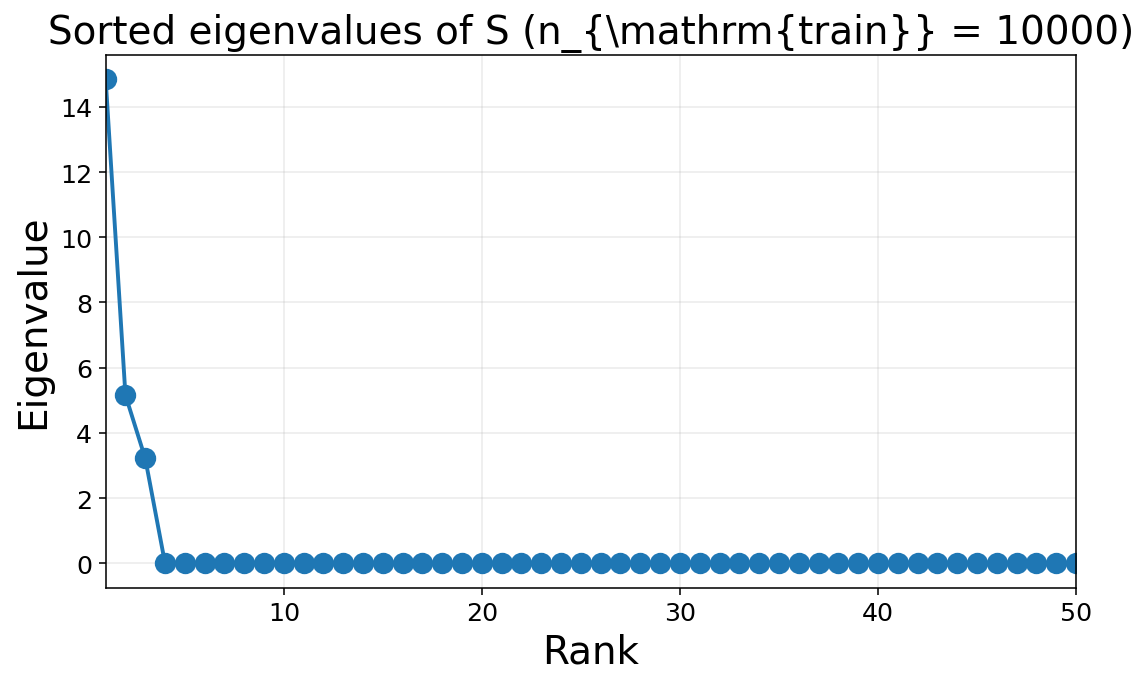

In [59]:
selected_ntrain = 10

eigvals = eigvals_by_ntrain[selected_ntrain]
eigvals_sorted = np.sort(eigvals)[::-1]

x_min = 1
x_max = len(eigvals_sorted)
y_min = None
y_max = None
use_log_y = False
marker = "o"
save_plot = False

fig, ax = plt.subplots()

ax.plot(
    np.arange(1, len(eigvals_sorted) + 1),
    eigvals_sorted,
    marker=marker,
)

ax.set_title(f"Sorted eigenvalues of S (n_{{\mathrm{{train}}}} = {ntrain})")
ax.set_xlabel("Rank")
ax.set_ylabel("Eigenvalue")
ax.grid(alpha=0.25)

ax.set_xlim(x_min, x_max)
if y_min is not None or y_max is not None:
    ax.set_ylim(y_min, y_max)

if use_log_y:
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

if save_plot:
    outpath = OUTPUT_DIR / f"eigvals_sorted_ntrain_{selected_ntrain}.png"
    fig.savefig(outpath)
    print(f"Saved to: {outpath}")

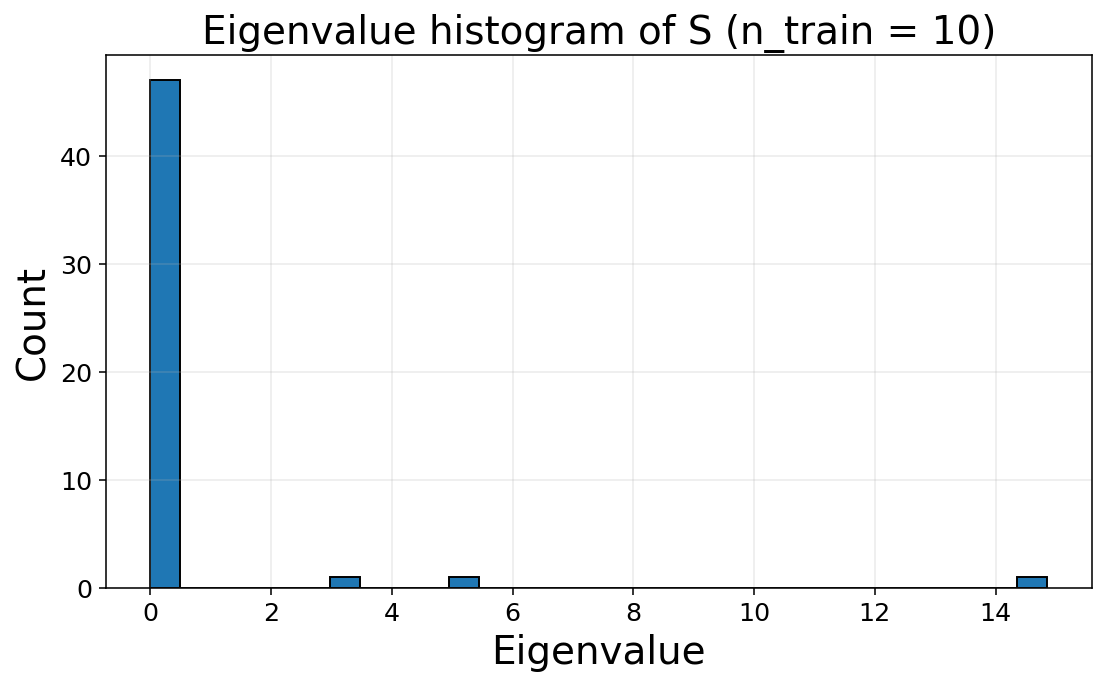

In [60]:
selected_ntrain = 10

eigvals = eigvals_by_ntrain[selected_ntrain]

bins = 30
hist_range = None          # example: (0, 2)
density = False
use_log_y = False
edgecolor = "black"
save_plot = False

vals = eigvals.copy()
if hist_range is not None:
    vals = vals[(vals >= hist_range[0]) & (vals <= hist_range[1])]

fig, ax = plt.subplots()

ax.hist(vals, bins=bins, density=density, edgecolor=edgecolor)

ax.set_title(f"Eigenvalue histogram of S (n_train = {selected_ntrain})")
ax.set_xlabel("Eigenvalue")
ax.set_ylabel("Density" if density else "Count")
ax.grid(alpha=0.25)

if hist_range is not None:
    ax.set_xlim(*hist_range)

if use_log_y:
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

if save_plot:
    outpath = OUTPUT_DIR / f"eigvals_hist_ntrain_{selected_ntrain}.png"
    fig.savefig(outpath)
    print(f"Saved to: {outpath}")

In [61]:
rows = []

for ntrain, eigvals in sorted(eigvals_by_ntrain.items()):
    eigvals = np.asarray(eigvals, dtype=float)
    eigvals_sorted = np.sort(eigvals)[::-1]

    rows.append({
    "n_train": ntrain,
    "num_eigs": len(eigvals),
    "min_eig": float(np.min(eigvals)),
    "max_eig": float(np.max(eigvals)),
    "mean_eig": float(np.mean(eigvals)),
    "median_eig": float(np.median(eigvals)),
    "std_eig": float(np.std(eigvals)),
    "trace": float(np.sum(eigvals)),
    "top_eigenvalue": float(eigvals_sorted[0]),
    "R1": float(eigvals_sorted[0] / np.sum(eigvals)),
    "effective_rank": effective_rank(eigvals),
})

df_stats = pd.DataFrame(rows).sort_values("n_train").reset_index(drop=True)
df_stats

,n_train,num_eigs,min_eig,max_eig,mean_eig,median_eig,std_eig,trace,top_eigenvalue,R1,effective_rank
0,10,50,6.759732e-17,14.855568,0.464661,1.429272e-11,2.222001,23.233044,14.855568,0.639415,2.444743
1,20,50,2.472464e-15,17.007960,0.558039,1.066376e-09,2.616512,27.901938,17.007960,0.609562,2.480730
2,30,50,5.664004e-15,22.309532,0.697925,1.653739e-09,3.269535,34.896268,22.309532,0.639310,2.768136
3,40,50,-1.674890e-17,27.170680,0.910507,4.815185e-09,4.007599,45.525373,27.170680,0.596825,3.287504
4,50,50,6.051529e-16,27.931512,0.835608,1.123206e-08,4.039208,41.780391,27.931512,0.668532,2.724763
5,75,50,9.866403e-16,15.987303,0.594286,1.017300e-09,2.431876,29.714281,15.987303,0.538034,3.647579
6,100,50,1.699474e-15,13.196073,0.497417,1.993726e-09,1.977131,24.870843,13.196073,0.530584,4.064697
7,125,50,7.492729e-17,8.549227,0.416150,3.919171e-10,1.354584,20.807515,8.549227,0.410872,5.677440
8,150,50,6.400704e-17,10.283089,0.467038,2.122866e-12,1.562613,23.351885,10.283089,0.440354,5.860787
9,175,50,7.540183e-16,7.778462,0.430661,1.371692e-10,1.314994,21.533057,7.778462,0.361234,6.103582


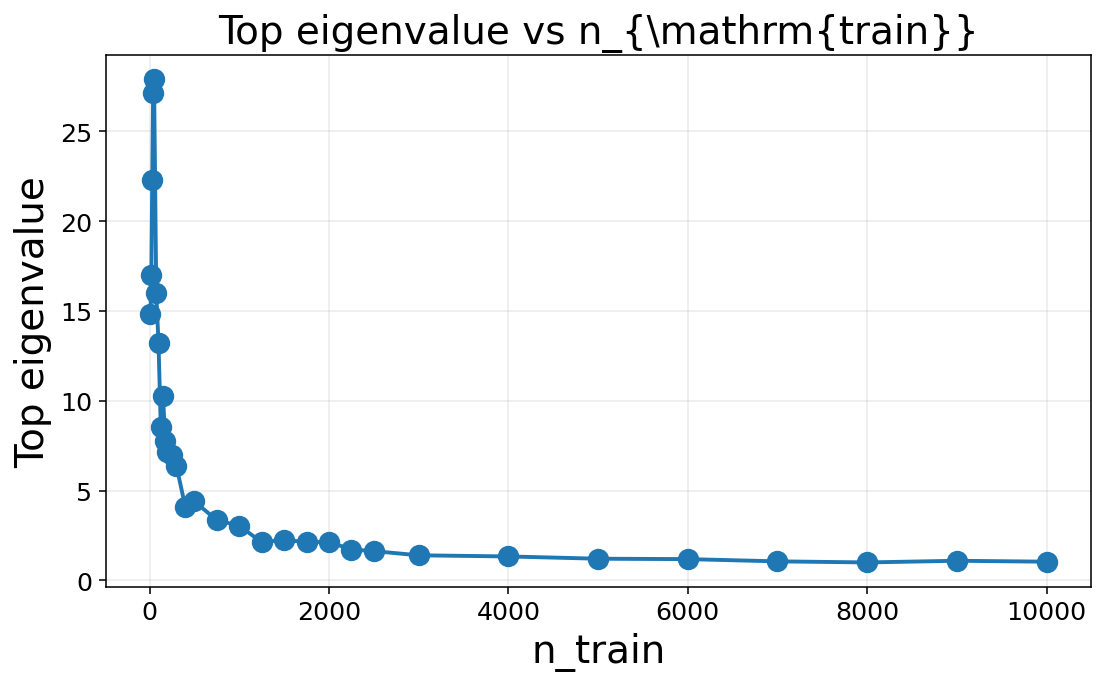

In [62]:
save_plot = False

fig, ax = plt.subplots()

ax.plot(
    df_stats["n_train"],
    df_stats["top_eigenvalue"],
    marker="o",
)

ax.set_title(rf"Top eigenvalue vs n_{{\mathrm{{train}}}}")
ax.set_xlabel("n_train")
ax.set_ylabel("Top eigenvalue")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

if save_plot:
    outpath = OUTPUT_DIR / "top_eigenvalue_vs_ntrain.png"
    fig.savefig(outpath)
    print(f"Saved to: {outpath}")

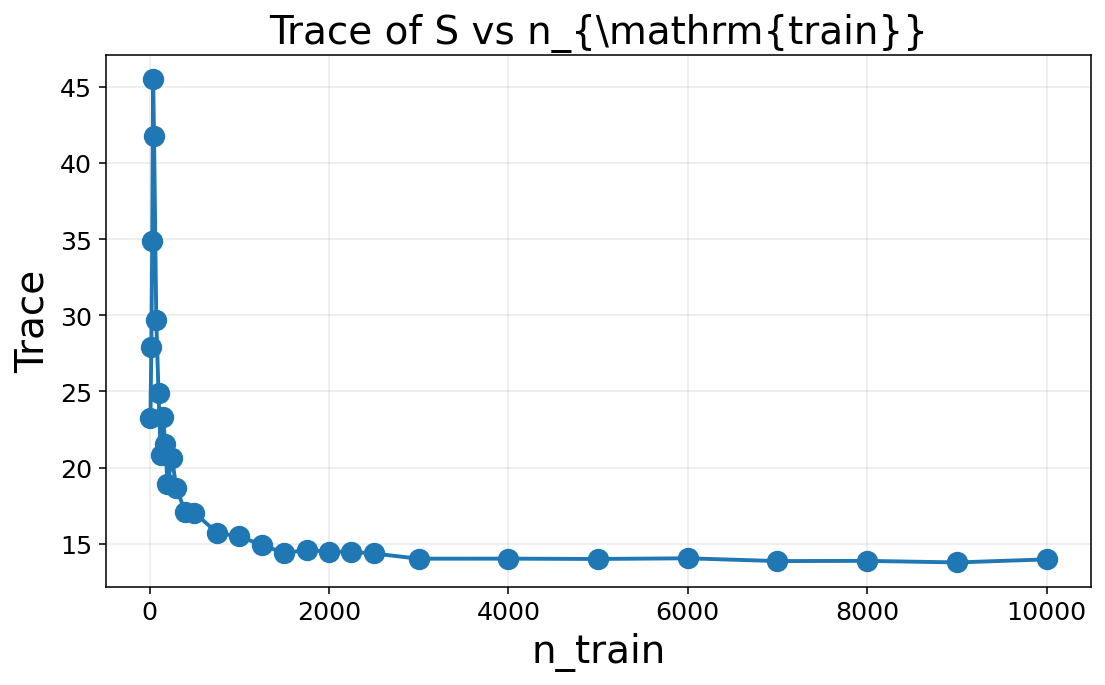

In [63]:
save_plot = False

fig, ax = plt.subplots()

ax.plot(
    df_stats["n_train"],
    df_stats["trace"],
    marker="o",
)

ax.set_title(rf"Trace of S vs n_{{\mathrm{{train}}}}")
ax.set_xlabel("n_train")
ax.set_ylabel("Trace")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

if save_plot:
    outpath = OUTPUT_DIR / "trace_vs_ntrain.png"
    fig.savefig(outpath)
    print(f"Saved to: {outpath}")

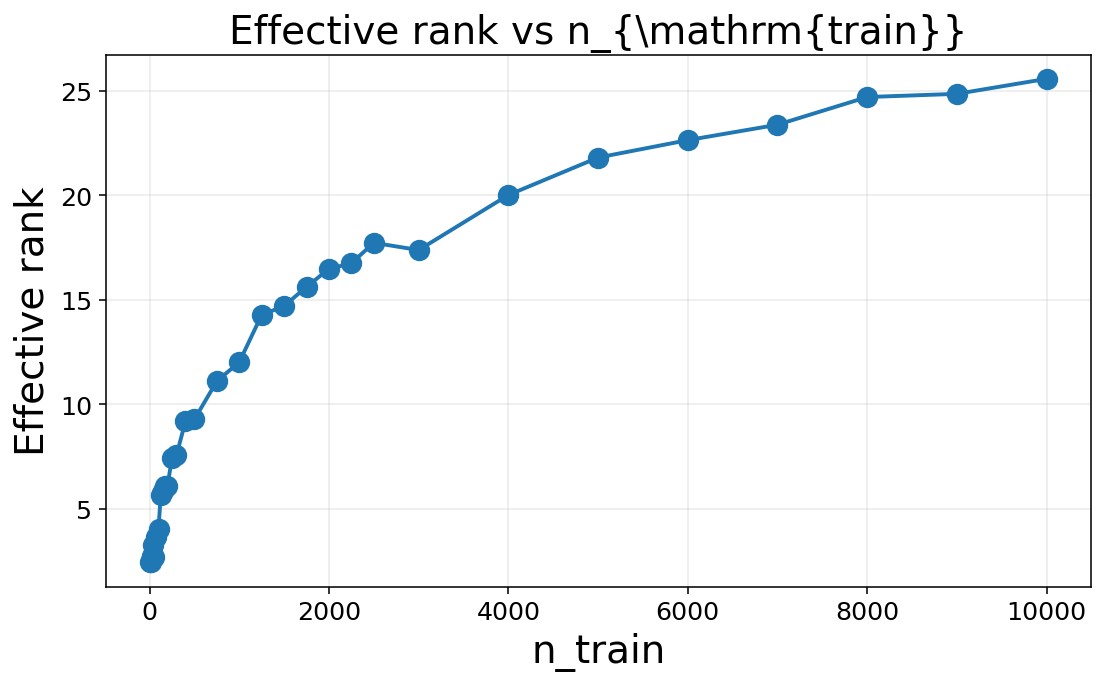

In [64]:
save_plot = False

fig, ax = plt.subplots()

ax.plot(
    df_stats["n_train"],
    df_stats["effective_rank"],
    marker="o",
)

ax.set_title(rf"Effective rank vs n_{{\mathrm{{train}}}}")
ax.set_xlabel("n_train")
ax.set_ylabel("Effective rank")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

if save_plot:
    outpath = OUTPUT_DIR / rf"effective_rank_vs_n_train.png"
    fig.savefig(outpath)
    print(f"Saved to: {outpath}")

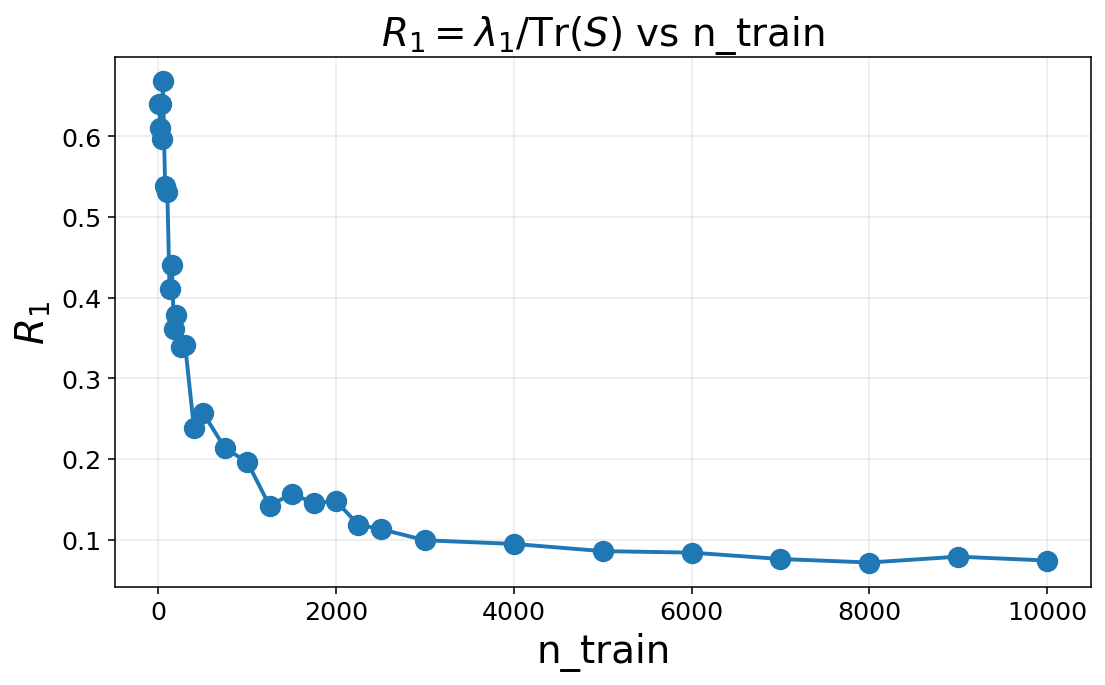

In [65]:
save_plot = False

fig, ax = plt.subplots()

ax.plot(
    df_stats["n_train"],
    df_stats["R1"],
    marker="o",
)

ax.set_title(r"$R_1 = \lambda_1 / \mathrm{Tr}(S)$ vs n_train")
ax.set_xlabel("n_train")
ax.set_ylabel(r"$R_1$")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

if save_plot:
    outpath = OUTPUT_DIR / "R1_vs_ntrain.png"
    fig.savefig(outpath)
    print(f"Saved to: {outpath}")

In [66]:
save_csv = True

if save_csv:
    csv_path = OUTPUT_DIR / "eigenvalue_summary_stats.csv"
    df_stats.to_csv(csv_path, index=False)
    print(f"Saved to: {csv_path}")

Saved to: /home/anastass/spoc-masked-attention/results/mask-random/presentation/iter_10000/cov_toeplitz_maskrandom_rho0p9_lambda1e-05_beta1_d50_T5_lr0p001_iter10000/clean_eigen_plots/eigenvalue_summary_stats.csv


In [67]:
save_all = True

x_min = 1
x_max = None
y_min = None
y_max = None
use_log_y = False
marker = "o"

if save_all:
    for ntrain, eigvals in sorted(eigvals_by_ntrain.items()):
        eigvals_sorted = np.sort(eigvals)[::-1]

        fig, ax = plt.subplots()
        ax.plot(
            np.arange(1, len(eigvals_sorted) + 1),
            eigvals_sorted,
            marker=marker,
        )

        ax.set_title(rf"Sorted eigenvalues of $S$ ($n_{{\mathrm{{train}}}} = {ntrain}$)")
        ax.set_xlabel("Rank")
        ax.set_ylabel("Eigenvalue")
        ax.grid(alpha=0.25)

        xmax = len(eigvals_sorted) if x_max is None else x_max
        ax.set_xlim(x_min, xmax)

        if y_min is not None or y_max is not None:
            ax.set_ylim(y_min, y_max)

        if use_log_y:
            ax.set_yscale("log")

        plt.tight_layout()
        outpath = OUTPUT_DIR / f"eigvals_sorted_ntrain_{ntrain}.png"
        fig.savefig(outpath)
        plt.close(fig)

    print("Saved all sorted eigenvalue plots.")

Saved all sorted eigenvalue plots.


In [68]:
save_all = False

bins = 30
hist_range = None
density = False
use_log_y = False
edgecolor = "black"

if save_all:
    for ntrain, eigvals in sorted(eigvals_by_ntrain.items()):
        vals = eigvals.copy()
        if hist_range is not None:
            vals = vals[(vals >= hist_range[0]) & (vals <= hist_range[1])]

        fig, ax = plt.subplots()
        ax.hist(vals, bins=bins, density=density, edgecolor=edgecolor)

        ax.set_title(rf"Eigenvalue histogram of S (n_{{\mathrm{{train}}}} = {ntrain})")
        ax.set_xlabel("Eigenvalue")
        ax.set_ylabel("Density" if density else "Count")
        ax.grid(alpha=0.25)

        if hist_range is not None:
            ax.set_xlim(*hist_range)

        if use_log_y:
            ax.set_yscale("log")

        plt.tight_layout()
        outpath = OUTPUT_DIR / f"eigvals_hist_ntrain_{ntrain}.png"
        fig.savefig(outpath)
        plt.close(fig)

    print("Saved all histogram plots.")